### 0. Importing

In [2]:
#%pip install xgboost
#%pip install lightgbm
import time 
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
from scipy import stats
from scipy.stats import f_oneway, chi2_contingency

df = pd.read_csv('PartI_dev.csv')
X = df.drop('Y', axis=1)
Y = df['Y']
print(df.Y.value_counts()) # We have 11 classes 
print(df.shape)
# =====================================================================
# DATA CLEANING/EXPLORATION
#
# =====================================================================
# Descriptive stats
print(df.describe())
print(df.info()) #All float values. No need for encoding.
print(df.isnull().sum()) # All defined values. No missing data.



# =====================================================================
# ANOVA F-TEST (appropriate for continuous features vs categorical target)
# =====================================================================
anova_results = []

for col in X.columns:
    groups = [X[col][Y == cls] for cls in Y.unique()]
    f_stat, p_val = f_oneway(*groups)
    anova_results.append({'Feature': col, 'F-Statistic': f_stat, 'P-Value': p_val})

anova_df = pd.DataFrame(anova_results).sort_values('F-Statistic', ascending=False)
anova_df['Significant'] = anova_df['P-Value'] < 0.05

print("=== ANOVA Results ===")
print(anova_df.to_string(index=False))

# =====================================================================
# CHI-SQUARED TEST (only valid for non-negative integer/categorical features)
# Binning floats into quartiles to make it applicable
# =====================================================================
chi2_results = []

for col in X.columns:
    binned = pd.qcut(X[col], q=4, labels=False, duplicates='drop')
    contingency_table = pd.crosstab(binned, Y)
    chi2_stat, p_val, dof, expected = chi2_contingency(contingency_table)
    chi2_results.append({'Feature': col, 'Chi2-Statistic': chi2_stat, 'P-Value': p_val, 'DOF': dof})

chi2_df = pd.DataFrame(chi2_results).sort_values('Chi2-Statistic', ascending=False)
chi2_df['Significant'] = chi2_df['P-Value'] < 0.05

print("\n=== Chi-Squared Results (binned into quartiles) ===")
print(chi2_df.to_string(index=False))

# =====================================================================
# SUMMARY — features significant in both tests
# =====================================================================
both_significant = set(anova_df[anova_df['Significant']]['Feature']) & \
                   set(chi2_df[chi2_df['Significant']]['Feature'])

print(f"\nFeatures significant in both tests ({len(both_significant)}):")
print(both_significant)


Y
1     4255
2     4255
3     4255
4     4255
5     4255
6     4255
7     4255
8     4255
9     4255
10    4255
11    4255
Name: count, dtype: int64
(46805, 49)
                 X1            X2            X3            X4            X5  \
count  46805.000000  46805.000000  46805.000000  4.680500e+04  46805.000000   
mean      -0.000003      0.000002      0.000002 -1.196022e-06      0.000001   
std        0.000075      0.000057      0.000256  6.524010e-05      0.000061   
min       -0.013756     -0.003989     -0.013538 -1.277087e-02     -0.008345   
25%       -0.000023     -0.000024     -0.000112 -1.877998e-05     -0.000024   
50%       -0.000003      0.000002      0.000002 -8.788122e-07      0.000001   
75%        0.000017      0.000027      0.000116  1.681469e-05      0.000027   
max        0.005807      0.004485      0.005403  1.461591e-03      0.000840   

                 X6            X7            X8            X9           X10  \
count  4.680500e+04  46805.000000  46805.000000 

<Axes: >

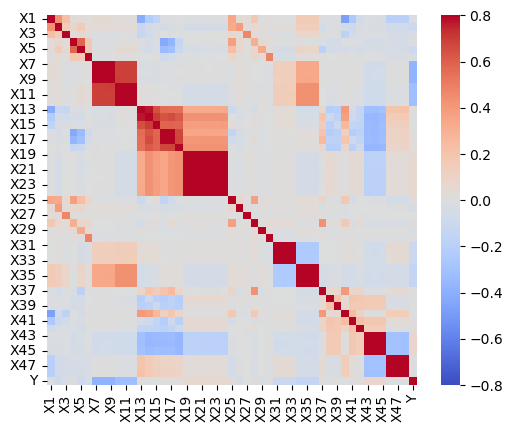

In [3]:
# =====================================================================
# Correlation matrix
#
# =====================================================================
sns.heatmap(df.corr(), square=True, vmax=.8, vmin=-.8, center=0, cmap='coolwarm')

# Correlation matrix shows elements of multicollinearity.
# When deciding the model we gotta be careful about multicollinearity as this will affect the model's performance
# additional considerations may be needed in terms of scaling and dimensionality reduction.


### Part 0 Data Prep

In [4]:
scalar = StandardScaler()
encoder = LabelEncoder()
pca = PCA()

data = df.copy()
Y = data['Y']
Y = encoder.fit_transform(Y) # apply just to prevent any mix ups with the model. We can decode the predictions later on.
X = data.drop(columns=['Y']).astype('float32') # Prevent excessive computation and memory usage
# 70/30 split for dev/test
x_dev, x_test, y_dev, y_test = train_test_split(X, Y, test_size=0.3, random_state=42, stratify=Y)

X_dev_scaled = scalar.fit_transform(x_dev)
X_test_scaled = scalar.transform(x_test)

print(f"X_dev shape: {x_dev.shape}, X_test shape: {x_test.shape}")
Y_dev = pd.DataFrame(y_dev, columns=['Y'])
Y_test = pd.DataFrame(y_test, columns=['Y'])
print(f"Y_dev shape: {Y_dev.value_counts()}, Y_test shape: {Y_test.value_counts()}")

X_dev shape: (32763, 48), X_test shape: (14042, 48)
Y_dev shape: Y 
5     2979
0     2979
10    2979
2     2979
9     2979
8     2978
6     2978
4     2978
3     2978
7     2978
1     2978
Name: count, dtype: int64, Y_test shape: Y 
1     1277
7     1277
8     1277
6     1277
4     1277
3     1277
9     1276
0     1276
2     1276
5     1276
10    1276
Name: count, dtype: int64


### PART 1

## For traditional I will be using ensemble methods

Due to the high concentration of features and classes the best model to choose would be RandomForest as a baseline then move in XGBoost and or LightGBM
- Why? The overall goal is generalization and efficiency since the models we will be implementating and testing on will see a unseen data set and also will have to generalize to 11 class and 48 features. Ensemble methods are robust to noise in that they average predictions from multiple learners. Additionally we want to prevent extensive hyperparameter tuning and have an easy way to deal with the level of multicolinearity from this data set so the procedure will be as follows

* Step 1: RandomForest hyper parameter tuning on X_Dev set -> Save results & params
* Step 2: XGBoost & LightGBM hyper parameter tuning on X_Dev Set -> Save results & params
* Step 3: Analysis 
* Step 4: Run best model on train and test set report results and possible reasons for issues.




###  Part 1 Model Hyperparameter selection


In [5]:
#========================================
# Model CV
#========================================
kfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9,None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10]
}
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'alpha': [0.01, 0.001, 0.0001]
}
'''param_grid_lgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.1, 0.01, 0.001],
    'reg_alpha': [0.01, 0.001, 0.0001,0],
    'reg_lambda': [0.01, 0.001, 0.0001,0]
}'''

grid_rf = GridSearchCV(RandomForestClassifier(n_jobs=-1,random_state=42, verbose=1), param_grid_rf, cv=kfold, scoring='f1_macro', n_jobs=-1, verbose=1) #Using a CPU with n_jobs=-1
grid_xgb = GridSearchCV(XGBClassifier(n_jobs=-1, random_state=42), param_grid_xgb, cv=kfold, scoring='f1_macro', n_jobs=-1) #Using a Cuda - GPU with tree_method="gpu_hist"
#grid_lgb = GridSearchCV(LGBMClassifier(n_jobs=-1, random_state=42,force_col_wise=True,objective='multiclass',device='gpu'), param_grid_lgb, cv=kfold, scoring='f1_macro', n_jobs=-1) #Using a Cuda - GPU with device='gpu'

In [6]:
grid_rf.fit(X_dev_scaled, y_dev)
best_params_rf = grid_rf.best_params_
best_score_rf = grid_rf.best_score_
    
print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best score for Random Forest:", grid_rf.best_score_)



Fitting 10 folds for each of 90 candidates, totalling 900 fits


c:\Users\tjmel\miniconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
grid_xgb.fit(X_dev_scaled, y_dev)

print("Best parameters for XGBoost:", grid_xgb.best_params_)
print("Best score for XGBoost:", grid_xgb.best_score_)


Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best score for XGBoost: 0.7470296991644054


In [ ]:
best_params_rf = grid_rf.best_params_
best_score_rf = grid_rf.best_score_

best_params_xgb = grid_xgb.best_params_
best_score_xgb = grid_xgb.best_score_

#best_params_lgb = grid_lgb.best_params_
#best_score_lgb = grid_lgb.best_score_

### Part 1.2 Model Training and Analysis

In [ ]:
rf = RandomForestClassifier(n_jobs=-1, random_state=42, **best_params_rf)
xg = XGBClassifier(n_jobs=-1, **best_params_xgb, random_state=42)  
#lg = LGBMClassifier(n_jobs=-1, **best_params_lgb, random_state=42)  

In [ ]:
print("Random Forest Training:")
start = time.time()
rf.fit(x_dev, y_dev)
print("Random Forest Training Time:", time.time() - start)

print("XGBoost Training:")
start = time.time()
xg.fit(x_dev, y_dev)
print("XGBoost Training Time:", time.time() - start)


Random Forest Training:
Random Forest Training Time: 5.534344911575317
XGBoost Training:
XGBoost Training Time: 14.783337354660034
LightGBM Training:
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002306 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12240
[LightGBM] [Info] Number of data points in the train set: 32763, number of used features: 48
[LightGBM] [Info] Start training from score -2.397712
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.397712
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.397712
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.398048
[LightGBM] [Info] Start training from score -2.397712
[LightGBM] [Info] St

In [ ]:
y_pred_rf = rf.predict(x_test)
y_pred_xg = xg.predict(x_test)

              precision    recall  f1-score   support

           0       0.57      0.79      0.66      1276
           1       0.68      0.64      0.66      1277
           2       0.64      0.65      0.64      1276
           3       0.69      0.76      0.72      1277
           4       0.56      0.40      0.46      1277
           5       0.59      0.36      0.45      1276
           6       0.93      0.98      0.96      1277
           7       0.64      0.66      0.65      1277
           8       0.64      0.63      0.64      1277
           9       0.65      0.75      0.70      1276
          10       1.00      1.00      1.00      1276

    accuracy                           0.69     14042
   macro avg       0.69      0.69      0.69     14042
weighted avg       0.69      0.69      0.69     14042



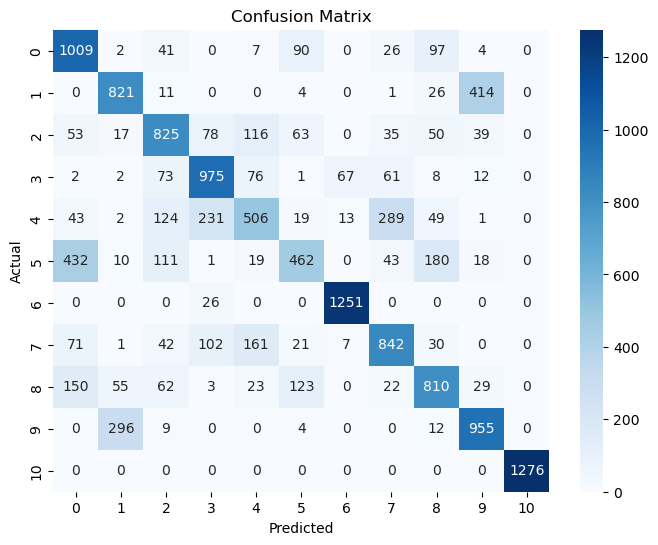

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print(classification_report(y_test, y_pred_rf))
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

              precision    recall  f1-score   support

           0       0.69      0.71      0.70      1276
           1       0.71      0.74      0.72      1277
           2       0.70      0.74      0.72      1276
           3       0.79      0.76      0.78      1277
           4       0.58      0.57      0.57      1277
           5       0.59      0.57      0.58      1276
           6       0.97      0.97      0.97      1277
           7       0.70      0.71      0.71      1277
           8       0.71      0.71      0.71      1277
           9       0.74      0.73      0.73      1276
          10       1.00      1.00      1.00      1276

    accuracy                           0.75     14042
   macro avg       0.75      0.75      0.75     14042
weighted avg       0.75      0.75      0.75     14042



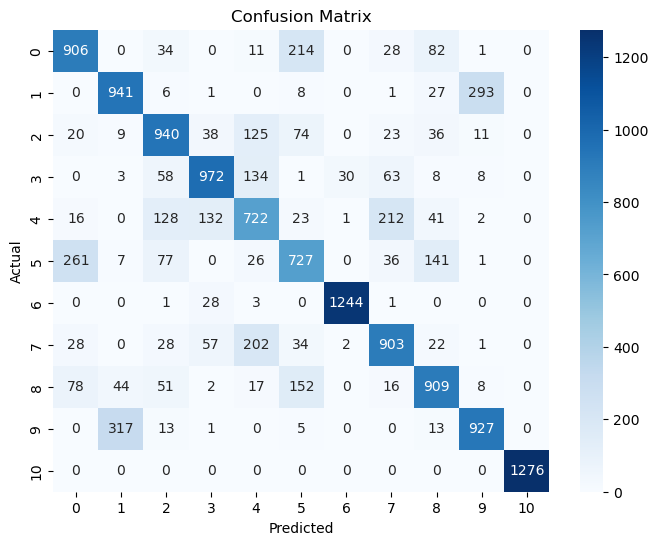

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
print(classification_report(y_test, y_pred_xg))
cm = confusion_matrix(y_test, y_pred_xg)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
forest_importances.plot.bar()
plt.title("Feature Importances (MDI)")
plt.show()

In [ ]:
importances = xg.feature_importances_
feature_names = X.columns

# Create a DataFrame for visualization
forest_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
forest_importances.plot.bar()
plt.title("Feature Importances (MDI)")
plt.show()

### Upon further analysis

Will be moving from simply just dropping features cause the removal hurts performance so will try applying L1 or L2 regularization to reduce features. Mainly L1


In [35]:
# =====================================================================
# Determine how many components to use in PCA when building our model. 
# We want to find the number of components that explain at least 95% of the variance in the data.
# =====================================================================
X = df.drop(columns=['Y'])  # Drop target if present
encoder = LabelEncoder()
Y = df['Y']  # Target variable
Y = encoder.fit_transform(Y)  # Encode target variable
# 70/20/10 split for train/test/validation

x_train, x_temp, y_train, y_temp = train_test_split(X, Y, stratify=Y, test_size=0.3, random_state=42)
x_val, x_test, y_val, y_test = train_test_split(x_temp, y_temp, stratify=y_temp, test_size=0.67, random_state=42)

print(x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape)

(32763, 48) (32763,) (4633, 48) (4633,) (9409, 48) (9409,)


In [ ]:


# Example classifiers for multiclass
classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'SVM': SVC(kernel='rbf', probability=True, decision_function_shape='ovr'),
    'Random Forest': RandomForestClassifier(n_estimators=100, n_jobs=-1),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

results = {}

for name, clf in classifiers.items():
    print(f'\n=== {name} ===')
    if name == 'Random Forest':
        pipe = ModelPipeline(model=clf, scale=False)
    else:
        pipe = ModelPipeline(model=clf, n_components=0.95, scale=True)
    pipe.fit(x_train, y_train)
    y_pred = pipe.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(y_test, y_pred))
    results[name] = acc

print("\nSummary of Accuracies:")
for name, acc in results.items():
    print(f"{name}: {acc:.4f}")





=== Logistic Regression ===
Accuracy: 0.6787
              precision    recall  f1-score   support

           0       0.62      0.67      0.64       855
           1       0.68      0.67      0.68       855
           2       0.63      0.67      0.65       855
           3       0.68      0.71      0.69       855
           4       0.48      0.41      0.44       856
           5       0.47      0.43      0.45       855
           6       0.97      0.96      0.96       856
           7       0.60      0.63      0.61       856
           8       0.61      0.62      0.62       856
           9       0.69      0.69      0.69       855
          10       1.00      1.00      1.00       855

    accuracy                           0.68      9409
   macro avg       0.68      0.68      0.68      9409
weighted avg       0.68      0.68      0.68      9409


=== SVM ===


KeyboardInterrupt: 

In [34]:

pipe = ModelPipeline(model=LogisticRegression(max_iter=1000, penalty='l2', C=2), scale=True)
pipe.fit(x_train, y_train)
#x_test_transformed = pipe.transform_only(x_test)  # Use this for test/validation data to avoid data leakage
# Assuming your features are in a DataFrame x_test
#x_test_transformed = pd.DataFrame(x_test_transformed, columns=[f'PC{i+1}' for i in range(x_test_transformed.shape[1])])
coefs = pd.DataFrame(pipe.model.coef_, columns=x_test.columns, index=pipe.model.classes_)
print(coefs.T)  # Features as rows, classes as columns
y_pred = pipe.predict(x_test)
acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print(classification_report(y_test, y_pred))

c:\Users\tjmel\OneDrive\Desktop\AML\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


           0         1         2         3         4         5         6   \
X1   0.087540 -0.018745  0.074437  0.086087 -0.237887  0.284872  0.075878   
X2   0.265340  0.304779  0.344264 -0.492119 -0.515265  0.390207  0.500486   
X3   0.143218  0.083243  0.043370 -0.247517 -0.214024  0.136742  0.313770   
X4  -0.033360 -0.222559 -0.177405  0.028339  0.036507 -0.344977  0.528777   
X5   0.690673  0.287632  0.537630 -0.842392 -0.750573  0.473342  0.968848   
X6   0.141831  0.067792  0.067920 -0.128826 -0.130858  0.171158  0.183003   
X7   2.260901 -3.729869  0.071731  0.741523  1.602158  1.034933  3.971516   
X8   2.183337 -3.793438  0.215755  0.782408  1.618293  1.012280  4.155251   
X9   2.247313 -3.723454 -0.004384  0.608228  1.448991  1.057109  4.103105   
X10 -2.603011 -2.080029  1.141521  3.618597  1.613525 -1.812880  6.378271   
X11 -2.725017 -1.812364  1.051404  3.655940  1.426337 -1.804394  6.492094   
X12 -2.726218 -1.897891  1.126852  3.608374  1.647312 -1.825752  6.373390   

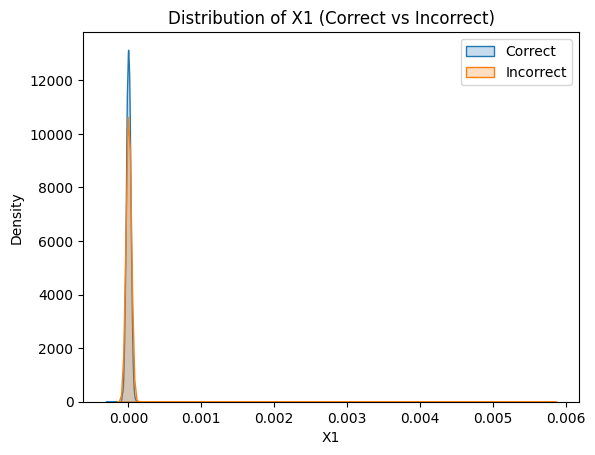

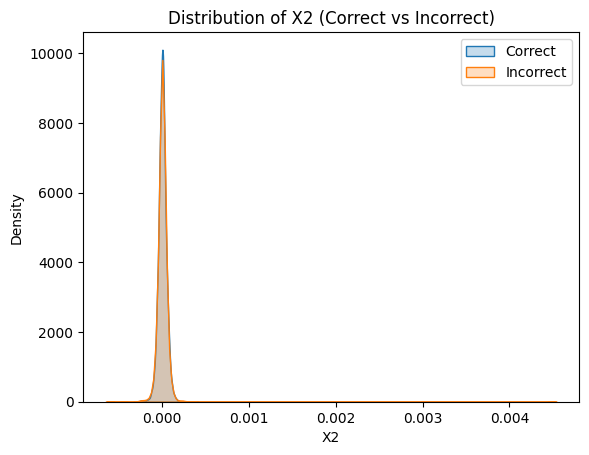

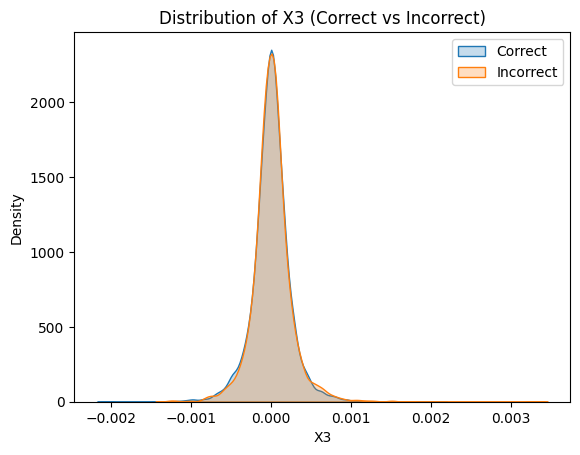

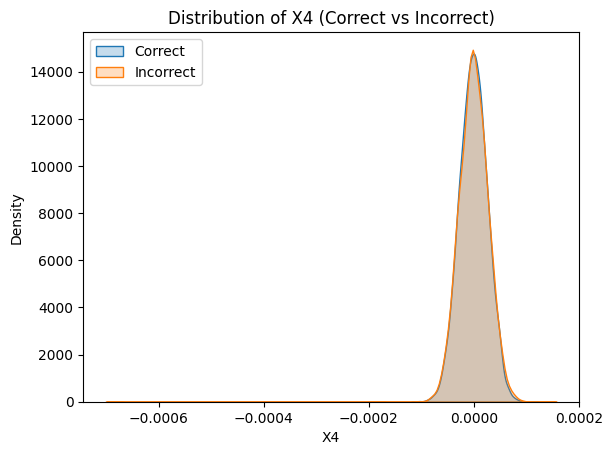

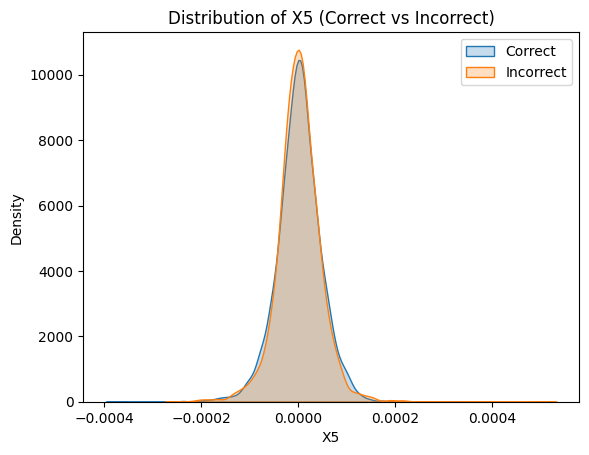

In [27]:
import numpy as np
wrong = y_test != y_pred
for col in x_test.columns[:5]:  # Check first 5 features
    plt.figure()
    sns.kdeplot(x_test.loc[~wrong, col], label='Correct', fill=True)
    sns.kdeplot(x_test.loc[wrong, col], label='Incorrect', fill=True)
    plt.title(f'Distribution of {col} (Correct vs Incorrect)')
    plt.legend()
    plt.show()